In [ ]:
#Data preprocessing and loading
install.packages(c("quantmod","tidyverse","tseries","forecast"))
library(tidyverse)
library(quantmod)
library(tseries)
library(forecast)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
getSymbols("^GSPC",src="yahoo",from = "2010-01-01",to= "2025-11-01")
Sp500_prices<- Ad(GSPC)
class(Sp500_prices)
Sp500_prices<-as.zoo(Sp500_prices)
#Sp500_prices<-apply.monthly(Sp500_prices, last)
print(sum(is.na(Sp500_prices)))

[1] "GSPC"

[1] "xts" "zoo"

[1] 0


In [ ]:
Sp500_df<-data.frame(
  date=index(Sp500_prices),
  price= as.numeric(Sp500_prices)
)
print(head(Sp500_df))

        date   price
1 2010-01-04 1132.99
2 2010-01-05 1136.52
3 2010-01-06 1137.14
4 2010-01-07 1141.69
5 2010-01-08 1144.98
6 2010-01-11 1146.98


In [ ]:
print(tail(Sp500_df))

           date   price
3978 2025-10-24 6791.69
3979 2025-10-27 6875.16
3980 2025-10-28 6890.89
3981 2025-10-29 6890.59
3982 2025-10-30 6822.34
3983 2025-10-31 6840.20


In [ ]:
sum(!is.na(Sp500_prices))

[1] 3983

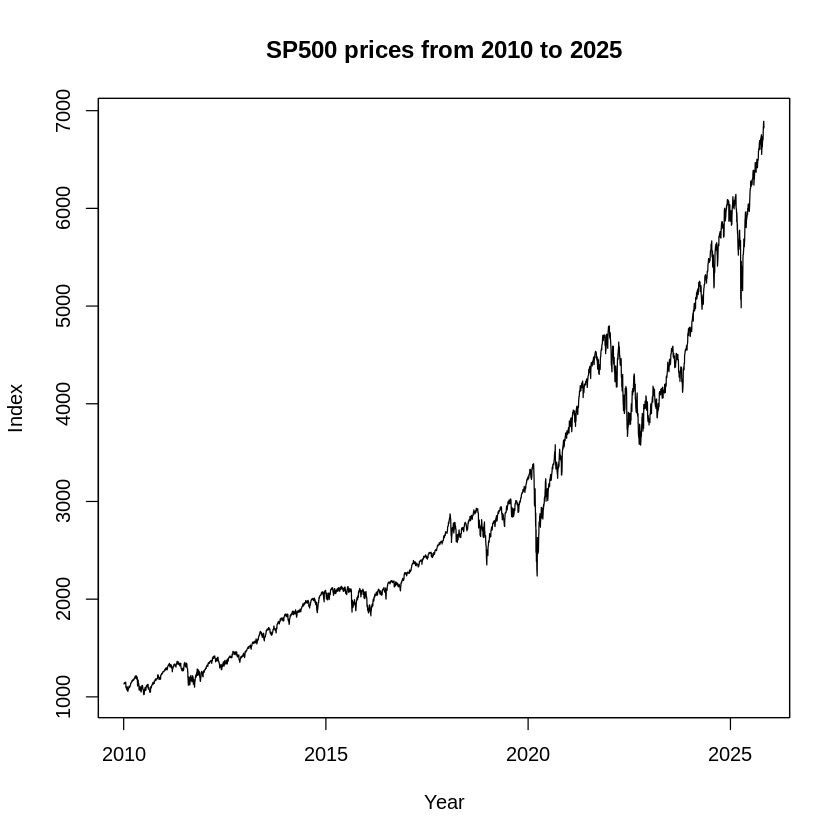

In [ ]:
plot(Sp500_prices,main="SP500 prices from 2010 to 2025", ylab="Index", xlab="Year",lwd=1)

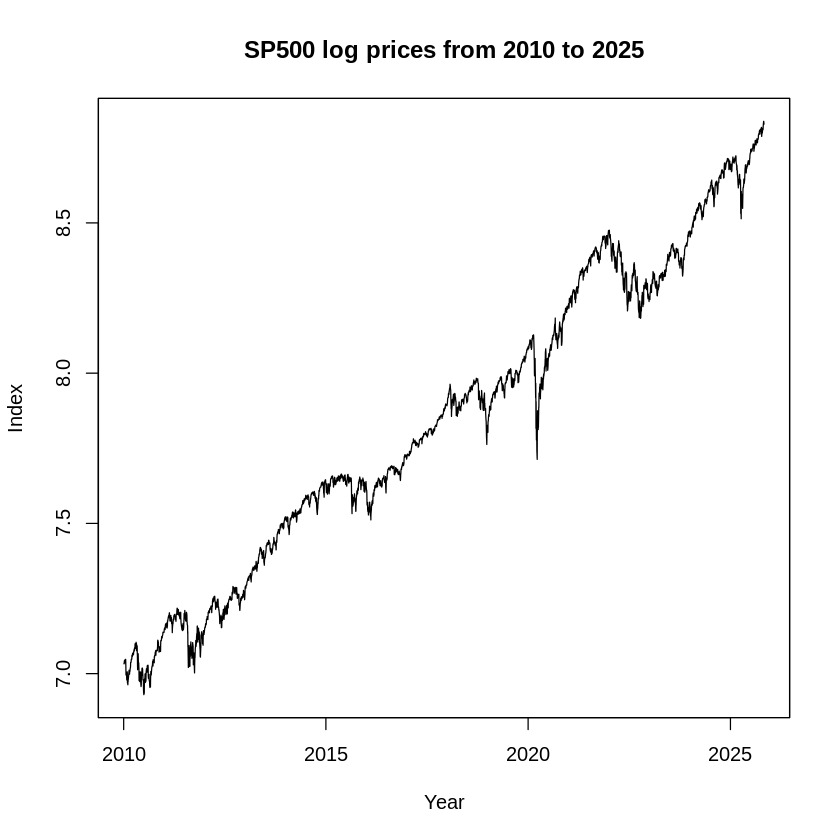

In [ ]:
plot(log(Sp500_prices),main="SP500 log prices from 2010 to 2025", ylab="Index", xlab="Year",lwd=1)

In [ ]:
adf.test(Sp500_prices)


	Augmented Dickey-Fuller Test

data:  Sp500_prices
Dickey-Fuller = -0.88848, Lag order = 15, p-value = 0.9537
alternative hypothesis: stationary


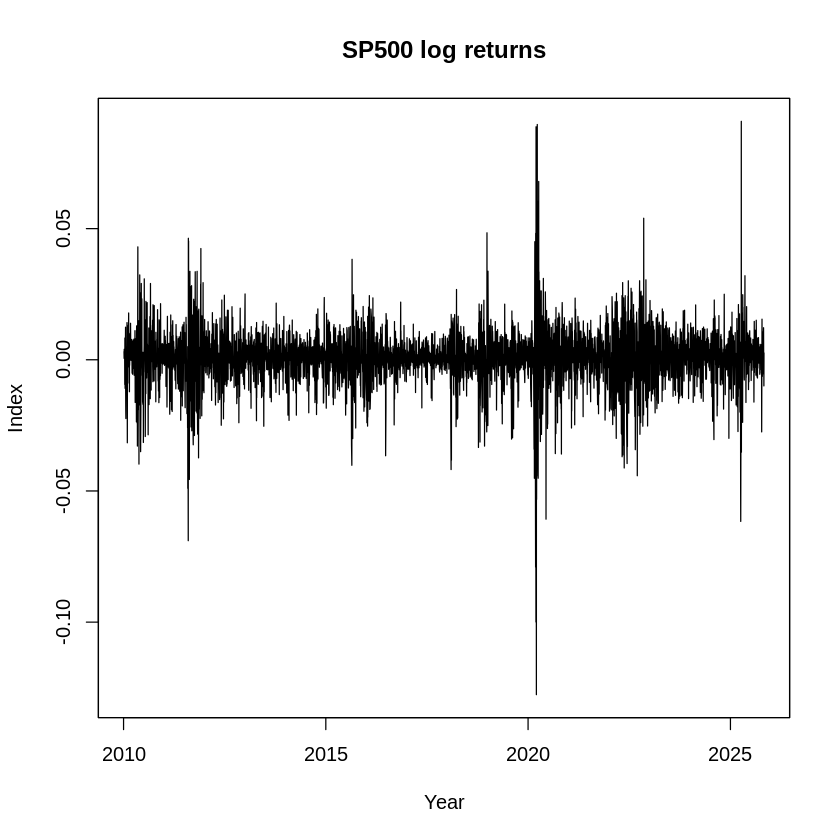

In [ ]:
Sp500_ret<-diff(log(Sp500_prices))
Sp500_ret<-na.omit(Sp500_ret)
plot(Sp500_ret,main="SP500 log returns", ylab="Index", xlab="Year",lwd=1)

In [ ]:
adf.test(Sp500_ret)

Warning message in adf.test(Sp500_ret):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  Sp500_ret
Dickey-Fuller = -16.448, Lag order = 15, p-value = 0.01
alternative hypothesis: stationary


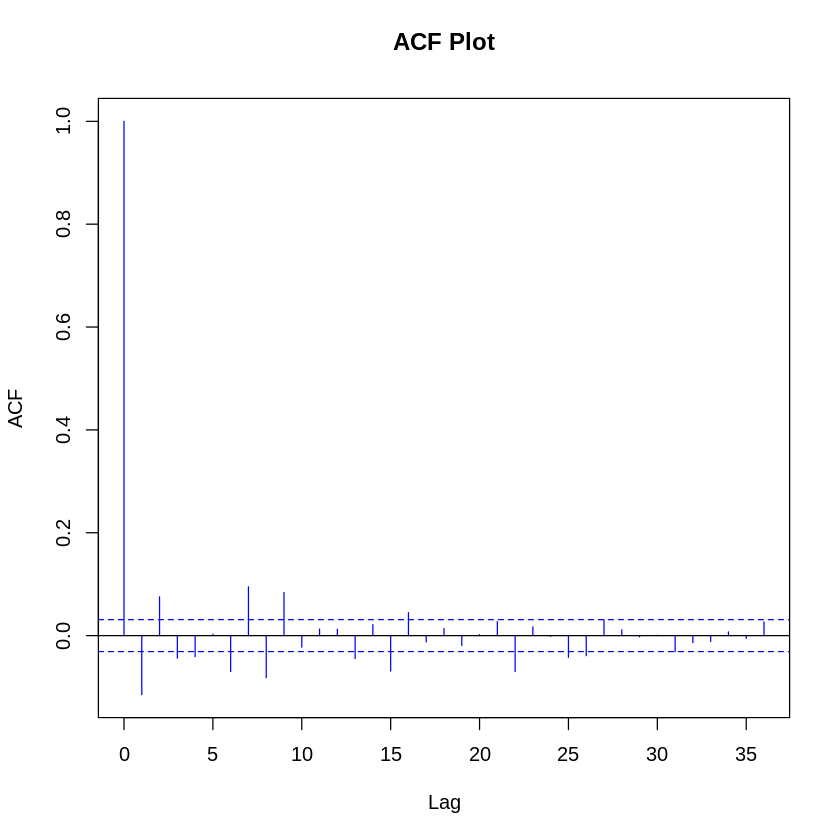

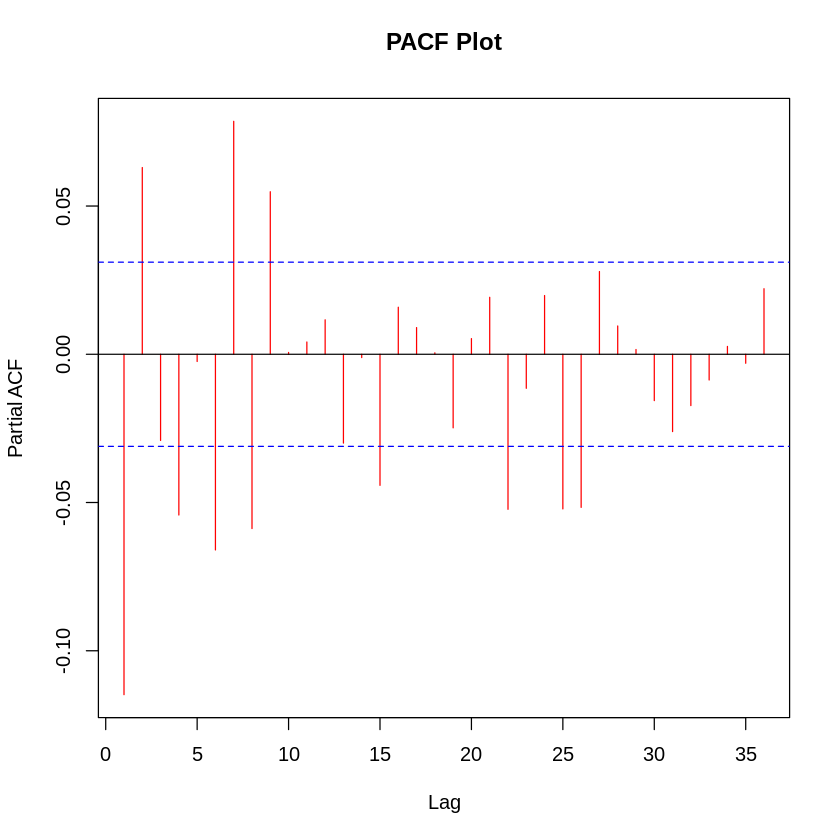

In [ ]:
acf(as.numeric(Sp500_ret), main="ACF Plot",col='blue')
pacf(as.numeric(Sp500_ret), main="PACF Plot",col='red')

In [ ]:
cutoff_date<-as.Date("2022-12-30")
in_sample<-Sp500_ret[index(Sp500_ret)<=cutoff_date]
out_sample <- Sp500_ret[index(Sp500_ret) > cutoff_date]

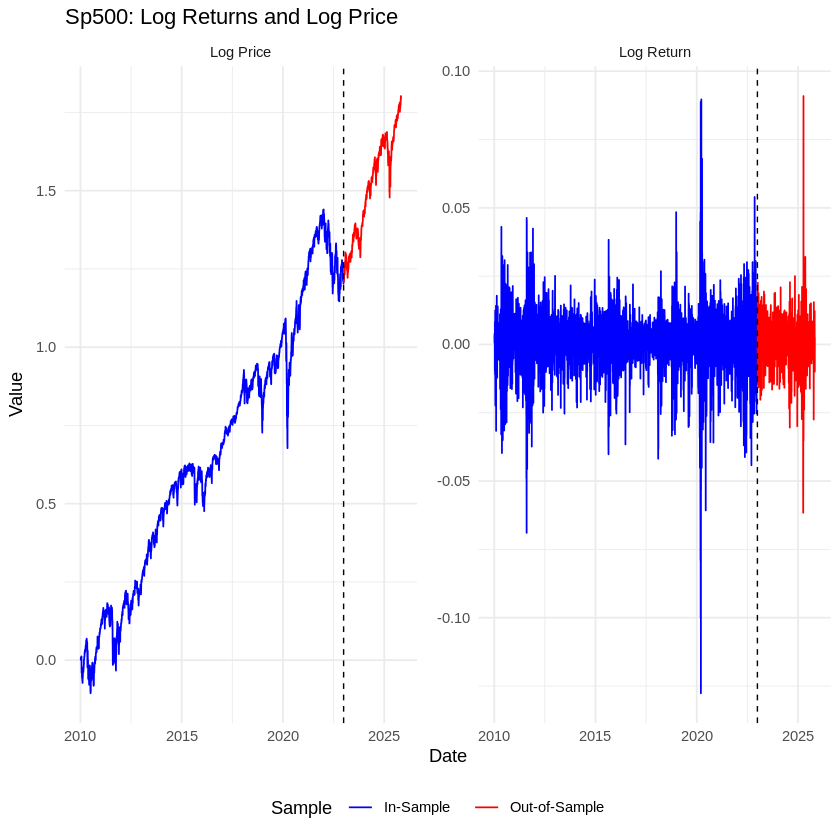

In [ ]:
# --- Reconstruct log price from log returns (up to an additive constant) ---
log_price <- cumsum(as.numeric(Sp500_ret))
log_price <- log_price - log_price[1] # start from 0
price_index <- exp(log_price) * 100 # base = 100
# --- Build combined data frame ---
data_df <- data.frame(
 Date = index(Sp500_ret),
 LogReturn = as.numeric(Sp500_ret),
 LogPrice = log_price,
 PriceIdx = price_index,
 Sample = ifelse(index(Sp500_ret) <= cutoff_date, "In-Sample", "Out-of-Sample")
)
# --- Reshape for plotting ---
plot_df <- rbind(
 data.frame(Date = data_df$Date, Value = data_df$LogReturn, Sample = data_df$Sample, Series = "Log Return"),
 data.frame(Date = data_df$Date, Value = data_df$LogPrice, Sample = data_df$Sample, Series = "Log Price")
 # Alternatively, use PriceIdx instead of LogPrice if you prefer to show rebased levels
)
ggplot(plot_df, aes(x = Date, y = Value, color = Sample)) +
 geom_line() +
 geom_vline(xintercept = cutoff_date, linetype = "dashed", size = 0.4) +
 facet_wrap(~ Series, ncol = 2, scales = "free_y") +
 labs(title = "Sp500: Log Returns and Log Price",
 x = "Date", y = "Value") +
 scale_color_manual(values = c("In-Sample" = "blue", "Out-of-Sample" = "red")) +
 theme_minimal() +
 theme(legend.position = "bottom")

In [ ]:
#MANUAL FITTING
manual_fit<-Arima(in_sample, order = c(1,0,1))
summary(manual_fit)

Series: in_sample 
ARIMA(1,0,1) with non-zero mean 

Coefficients:
          ar1    ma1   mean
      -0.5612  0.432  4e-04
s.e.   0.0818  0.089  2e-04

sigma^2 = 0.0001239:  log likelihood = 10064.33
AIC=-20120.66   AICc=-20120.65   BIC=-20094.8

Training set error measures:
                        ME       RMSE         MAE  MPE MAPE      MASE
Training set -4.662378e-06 0.01112415 0.007337349 -Inf  Inf 0.6667534
                    ACF1
Training set 0.009437256

In [ ]:
auto_fit<-auto.arima(in_sample, d=0)
summary(auto_fit)

Series: in_sample 
ARIMA(1,0,0) with non-zero mean 

Coefficients:
          ar1   mean
      -0.1351  4e-04
s.e.   0.0197  2e-04

sigma^2 = 0.0001244:  log likelihood = 10059.06
AIC=-20112.12   AICc=-20112.12   BIC=-20092.73

Training set error measures:
                       ME       RMSE        MAE  MPE MAPE      MASE       ACF1
Training set 1.787919e-06 0.01115183 0.00735416 -Inf  Inf 0.6682811 0.01230179


	Ljung-Box test

data:  Residuals from ARIMA(1,0,1) with non-zero mean
Q* = 578.92, df = 8, p-value < 2.2e-16

Model df: 2.   Total lags used: 10



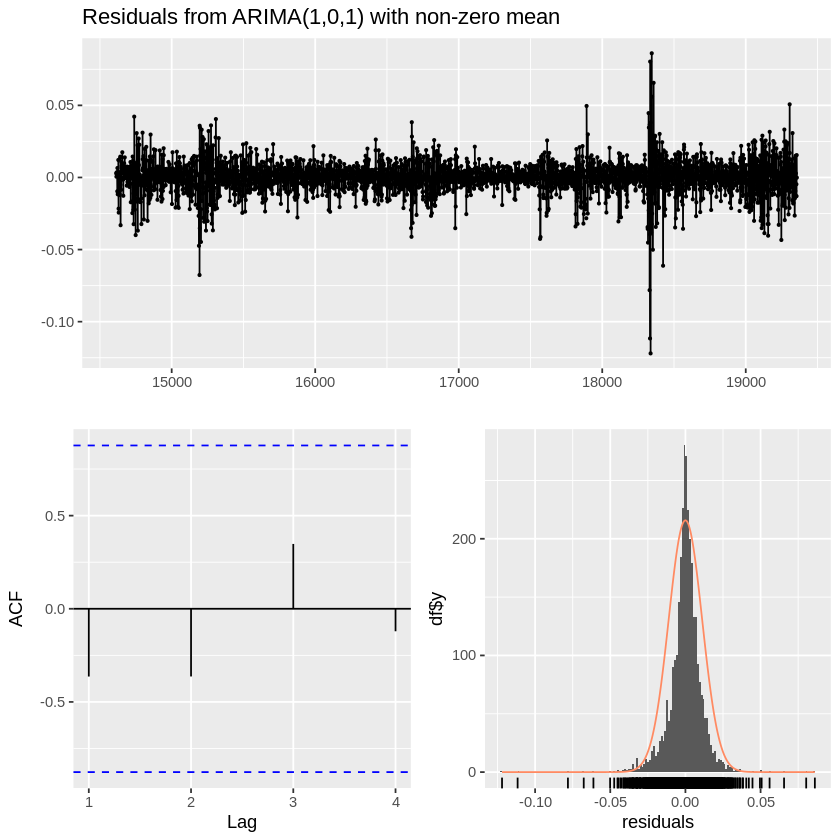


	Ljung-Box test

data:  Residuals from ARIMA(1,0,0) with non-zero mean
Q* = 603.24, df = 9, p-value < 2.2e-16

Model df: 1.   Total lags used: 10



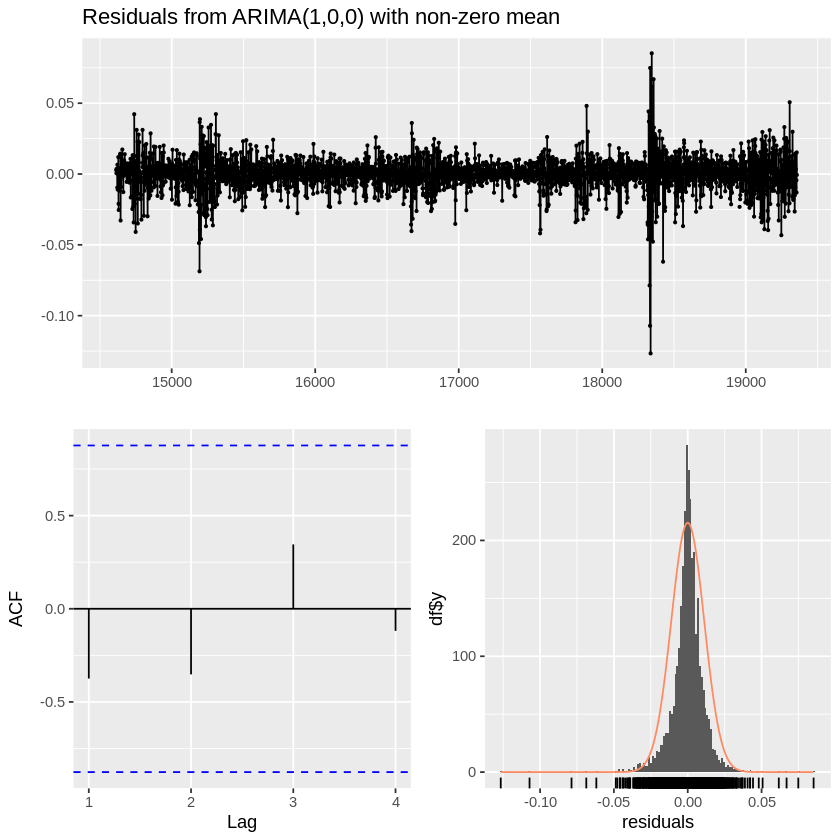

In [ ]:
checkresiduals(manual_fit)
checkresiduals(auto_fit)

         Model       RMSE         MAE
1 ARIMA(1,0,1) 0.01067747 0.008713958
2   auto.arima 0.01055880 0.008563686


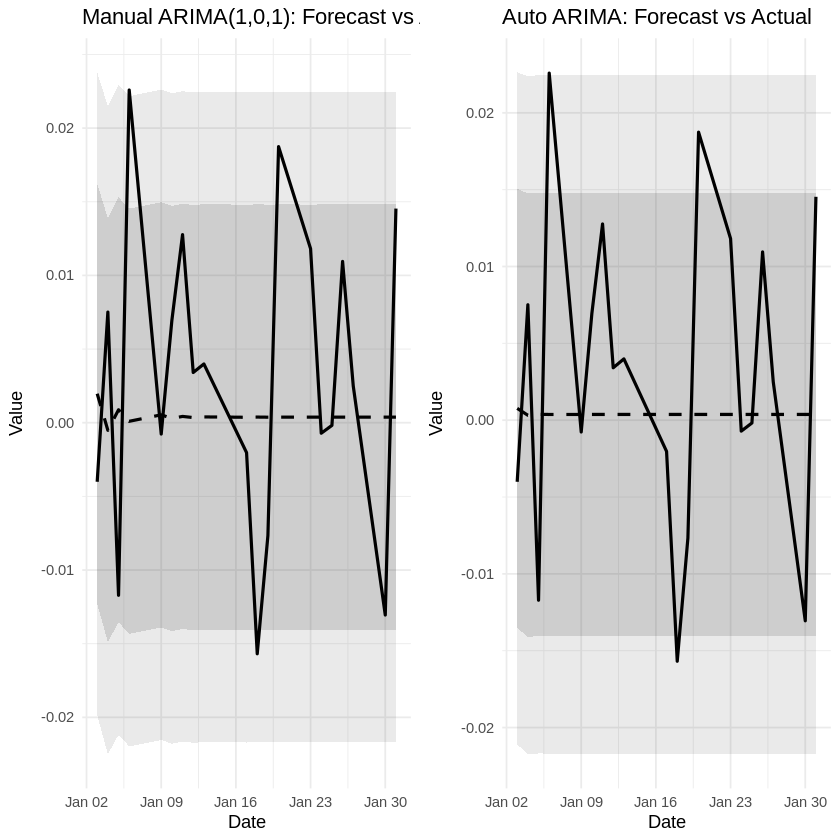

In [ ]:
# Forecast horizon
h <- min(20, NROW(out_sample))
# Prepare actual OOS data (first h points)
oos_actual <- out_sample[1:h]
oos_df <- data.frame(
 Date = as.Date(time(oos_actual)),
 Actual = as.numeric(coredata(oos_actual))
)
# Forecasts
manual_fc <- forecast(manual_fit, h = h)
auto_fc <- forecast(auto_fit, h = h)
# Build tidy frames for plotting, aligned to OOS dates
manual_df <- data.frame(
 Date = oos_df$Date,
 Mean = as.numeric(manual_fc$mean),
 Lo80 = as.numeric(manual_fc$lower[,"80%"]),
 Hi80 = as.numeric(manual_fc$upper[,"80%"]),
 Lo95 = as.numeric(manual_fc$lower[,"95%"]),
 Hi95 = as.numeric(manual_fc$upper[,"95%"])
)
auto_df <- data.frame(
 Date = oos_df$Date,
 Mean = as.numeric(auto_fc$mean),
 Lo80 = as.numeric(auto_fc$lower[,"80%"]),
 Hi80 = as.numeric(auto_fc$upper[,"80%"]),
 Lo95 = as.numeric(auto_fc$lower[,"95%"]),
 Hi95 = as.numeric(auto_fc$upper[,"95%"])
)
# Plot: auto.arima vs actual (first h OOS points)
p_manual <- ggplot() +
 geom_ribbon(data = manual_df, aes(x = Date, ymin = Lo95, ymax = Hi95), alpha = 0.10) +
 geom_ribbon(data = manual_df, aes(x = Date, ymin = Lo80, ymax = Hi80), alpha = 0.15) +
 geom_line(data = oos_df, aes(x = Date, y = Actual), size = 0.9) +
 geom_line(data = manual_df, aes(x = Date, y = Mean), linetype = "dashed", size = 0.9) +
 labs(title = "Manual ARIMA(1,0,1): Forecast vs Actual",
 x = "Date", y = "Value") +
 theme_minimal() +
 theme(legend.position = "none")

p_auto <- ggplot() +
 geom_ribbon(data = auto_df, aes(x = Date, ymin = Lo95, ymax = Hi95), alpha = 0.10) +
 geom_ribbon(data = auto_df, aes(x = Date, ymin = Lo80, ymax = Hi80), alpha = 0.15) +
 geom_line(data = oos_df, aes(x = Date, y = Actual), size = 0.9) +
 geom_line(data = auto_df, aes(x = Date, y = Mean), linetype = "dashed", size = 0.9) +
 labs(title = "Auto ARIMA: Forecast vs Actual",
 x = "Date", y = "Value") +
 theme_minimal() +
 theme(legend.position = "none")

# Arrange side by side
grid.arrange(p_manual, p_auto, ncol = 2)
## Optional: quick accuracy table for the first h OOS points
auto_err <- oos_df$Actual - auto_df$Mean
manual_err <- oos_df$Actual - manual_df$Mean
acc_df <- data.frame(
 Model = c("ARIMA(1,0,1)", "auto.arima"),
 RMSE = c(sqrt(mean(manual_err^2, na.rm = TRUE)),
 sqrt(mean(auto_err^2, na.rm = TRUE))),
 MAE = c(mean(abs(manual_err), na.rm = TRUE),
 mean(abs(auto_err), na.rm = TRUE))
)
print(acc_df)

In [ ]:
install.packages("gridExtra")
library(gridExtra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [ ]:
# Manual ARIMA performance
manual_accuracy <- accuracy(manual_fc, out_sample[1:20])
print(manual_accuracy)
# Auto ARIMA performance
auto_accuracy <- accuracy(auto_fc, out_sample[1:20])
print(auto_accuracy)

                        ME       RMSE         MAE      MPE     MAPE      MASE
Training set -4.662378e-06 0.01112415 0.007337349     -Inf      Inf 0.6667534
Test set      2.567004e-03 0.01067747 0.008713958 118.4118 118.4118 0.7918475
                    ACF1
Training set 0.009437256
Test set              NA
                       ME       RMSE         MAE     MPE    MAPE      MASE
Training set 1.787919e-06 0.01115183 0.007354160    -Inf     Inf 0.6682811
Test set     2.604440e-03 0.01055880 0.008563686 114.873 114.873 0.7781921
                   ACF1
Training set 0.01230179
Test set             NA



Manual ARIMA(1,0,1) Ljung–Box test:

	Box-Ljung test

data:  manual_resid
X-squared = 3.6409, df = 10, p-value = 0.9621

Auto ARIMA Ljung–Box test:

	Box-Ljung test

data:  auto_resid
X-squared = 3.6906, df = 10, p-value = 0.9602



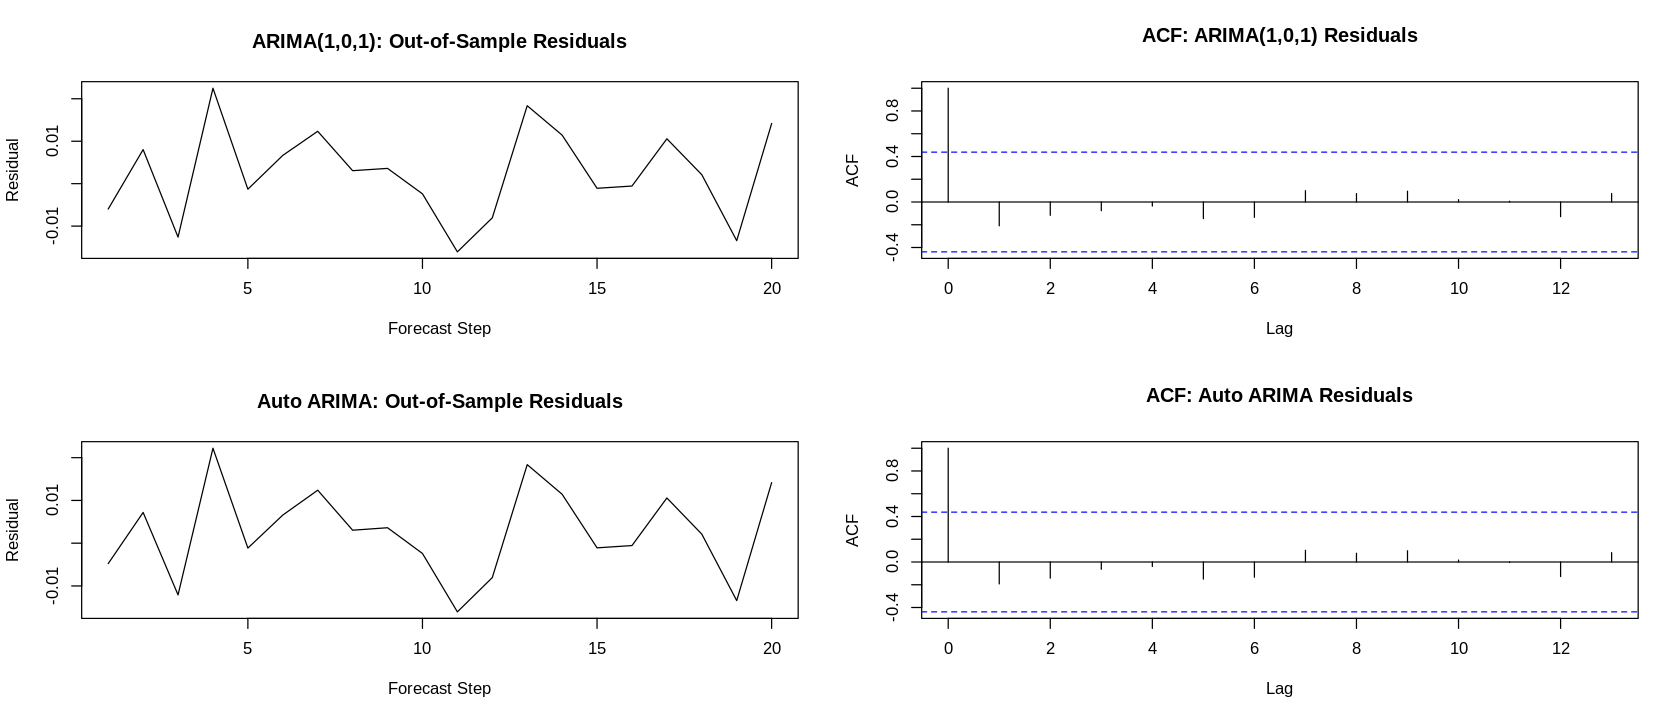

In [ ]:
# Convert both series to numeric vectors
actual_vals <- as.numeric(out_sample[1:20])
auto_preds <- as.numeric(auto_fc$mean)
manual_preds <- as.numeric(manual_fc$mean)
# Compute forecast residuals
auto_resid <- actual_vals - auto_preds
manual_resid <- actual_vals - manual_preds
# Plot residuals and ACFs
par(mfrow = c(2, 2))
plot(manual_resid, type = "l", main = "ARIMA(1,0,1): Out-of-Sample Residuals",
 ylab = "Residual", xlab = "Forecast Step")
acf(manual_resid, main = "ACF: ARIMA(1,0,1) Residuals")
plot(auto_resid, type = "l", main = "Auto ARIMA: Out-of-Sample Residuals",
 ylab = "Residual", xlab = "Forecast Step")
acf(auto_resid, main = "ACF: Auto ARIMA Residuals")
par(mfrow = c(1, 1))
# Ljung–Box tests for residual autocorrelation
cat("\nManual ARIMA(1,0,1) Ljung–Box test:\n")
print(Box.test(manual_resid, lag = 10, type = "Ljung-Box"))
cat("Auto ARIMA Ljung–Box test:\n")
print(Box.test(auto_resid, lag = 10, type = "Ljung-Box"))